In [5]:
import numpy as np
from pathlib import Path


#! VOGLIO MORIRE
data = np.load( "../solutions/transient.npy").T

data.shape

(3, 100)

<ErrorbarContainer object of 3 artists>

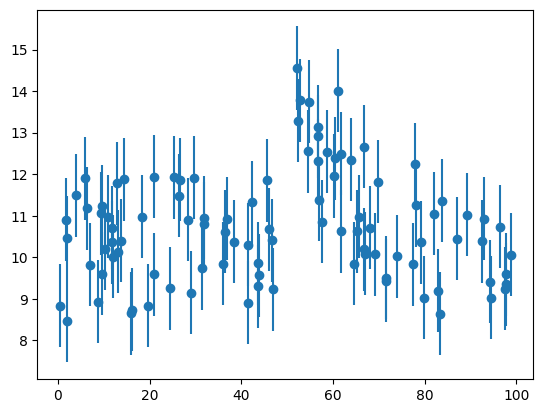

In [3]:
import matplotlib.pyplot as plt

plt.errorbar(data[0], data[1], data[2], marker="o", linestyle="none")

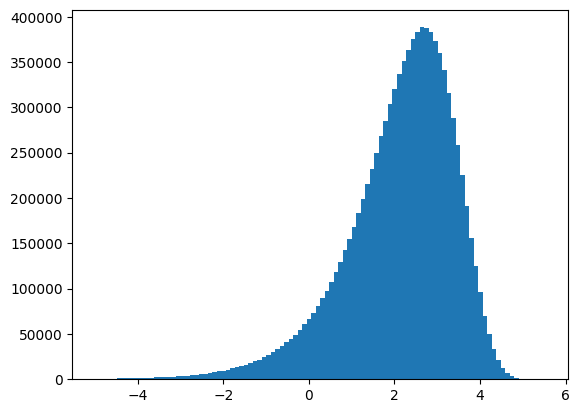

In [31]:
from scipy.stats import uniform, expon
import matplotlib.pyplot as plt

dist = uniform(loc= -5 , scale = 10)

data = dist.rvs(int(1e7))
# plt.hist(data)
exp_data = np.exp(data)
# plt.hist(exp_data, bins = 100);

exp_params = expon.fit(exp_data, loc=0, scale=np.exp(10))

l_dist = expon( *exp_params)

plt.hist(np.log(l_dist.rvs(int(1e7))), bins = 100);




In [ ]:
from scipy.stats import expon, norm

b_range = (0,50)
A_range = (0,50)
t0_range = (0,100)
lnl_range = (-5,5)

l_range = np.exp(lnl_range)

def model( x , t0 , A , l , b):
    return b + A*expon.pdf(x , loc = t0 , scale = 1/l)

def likelyhood( x , y , y_err , model, params):
    return np.prod(norm.pdf(y - model(x , *params) , loc = 0 , scale = y_err))

def logLikelyhood( params , x , y, y_err, model = model):
    y_fit = model(x, *params)
    return np.sum( norm.logpdf(y - y_fit, loc = 0 , scale = y_err))

def Prior(params):
    t0, A, l, b = params
    if (
        t0_range[0] <= t0 <= t0_range[1]
        and A_range[0] <= A <= A_range[1]
        and b_range[0] <= b <= b_range[1]
        and l_range[0]<= l <= l_range[1]):
        return 
    return -np.inf





In [19]:
import emcee

ndim = 4
nwalkers = 10
nsteps = int(1e6)

starting_guesses = np.random.random((nwalkers, ndim))



sampler = emcee.EnsembleSampler(nwalkers, ndim, Posterior , args=[data[0] , data[1] , data[2]])

sampler.run_mcmc(starting_guesses, nsteps)

ValueError: Probability function returned NaN